## FRAP analyses - interpretation

___

In [1]:
from pathlib import Path
from microlive.pipelines.pipeline_FRAP import *
from microlive.imports import *
from microlive import microscopy as mi
# Import plotting functions from module
from frap_utilities import (
    plot_images_frap_all_channels_representative,
    plot_kymograph,
    plot_merged_image,
    plot_combined_cell_and_kymograph,
    plot_cell_images_individual,
    save_video_as_avi,
    compose_pngs,
    save_image_as_tiff,
)

In [2]:
# Paths
current_dir = Path().resolve()
one_drive_dir = mi.Utilities.get_one_drive_dir()
path_main_folder = one_drive_dir.joinpath('General - Zhao (NZ) Lab/Microscope/Rhiannon (microscope)/LaG16 Binding Stiochiometry/LaG16 FRAP/Finished Analysis')
cwd = Path().resolve()
results_folder = cwd / ('results/kymographs_representative')
results_folder.mkdir(parents=True, exist_ok=True)

## Parameters
___

In [3]:
frap_time = 10
stable_FRAP_channel = 1 
FRAP_channel_to_quantify = 0
radius_roi_size_px=14
starting_changing_frame=10
step_size_increase=2
length_kymograph_line = 50
min_size_image = 230
scalebar_size = 0 # font size for the scale bar.
save_tif = False
crop_size = 250
show_circle= False
cmap_list = [green_colormap, magenta_colormap]
line_color_FRAP = 'yellow' # select the color for the FRAP line
list_selected_frame_values_real_time =[0, 11, 50, 100, 300, 500] 
x_title_list = ['', '^', ' 50s', '100s', '300s', '500s']
list_datasets = ['FRAP_fast','FRAP_slow']
# plot settings
save_avi = True
show_combined_kymograph = True
show_kymograph_simple = True
show_individual_images = True  # Generate individual channel images + merge


### Main functions
____

In [4]:
def get_data_folder_path(dataset='FRAP_fast'):
    if dataset == 'FRAP_fast':
        # modify the following lines as needed
        data_folder_path = path_main_folder.joinpath('20250709 pRS046_050 FRAP.lif')
        plot_name = '20250709 sfGFP-011'
        selected_image_name = 'FRAP 011'
        start_x = 100
        start_y = 80
        ch0_label = 'Anti-GFP-ib-mSG'
        ch1_label = 'GFP-mCh-H2B'
        # dont modify the following lines.
        y_label_list = [ch0_label, ch1_label]
        end_x = start_x+crop_size  
        end_y = start_y+crop_size 
        list_axis_limits = [start_x, end_x, start_y, end_y] 
    else:
        data_folder_path = path_main_folder.joinpath('20250828 pRS056_050 FRAP.lif')
        plot_name = '20250828 uvGFP-009'
        selected_image_name = 'FRAP 009'
        start_x = 100
        start_y = 80
        ch0_label = 'Anti-GFP-ib-mSG'
        ch1_label = 'GFP-mCh-H2B'
        # dont modify the following lines.
        y_label_list = [ch0_label, ch1_label]
        end_x = start_x+crop_size  
        end_y = start_y+crop_size 
        list_axis_limits = [start_x, end_x, start_y, end_y] 
    return data_folder_path, selected_image_name, list_axis_limits, y_label_list, plot_name

### Running
___

Image with shape (T Z Y X C):
  (310, 1, 512, 512, 2)
Original Image pixel  min: 0.00, max: 237.00, mean: 7.58, std: 20.60


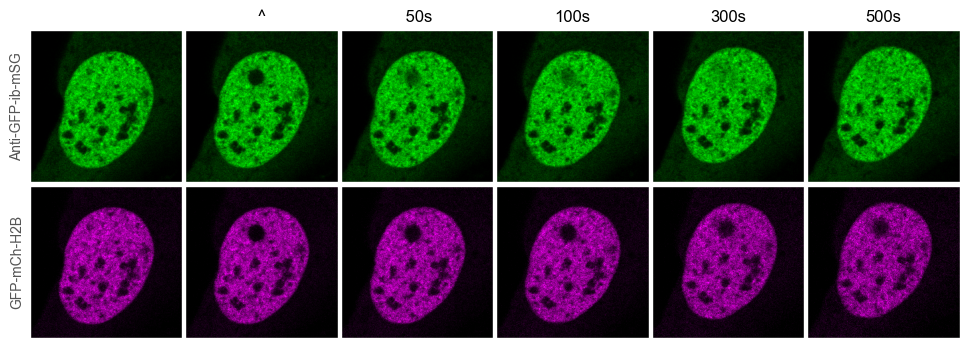

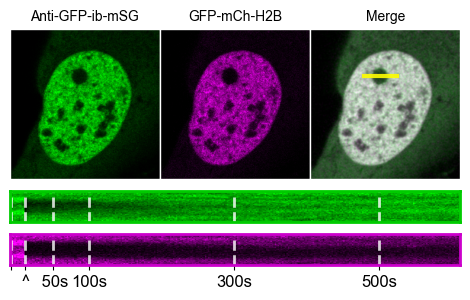

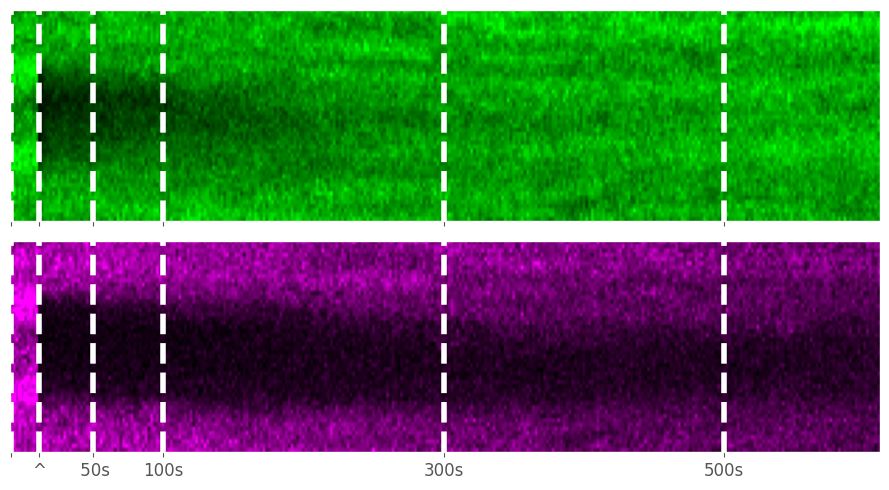

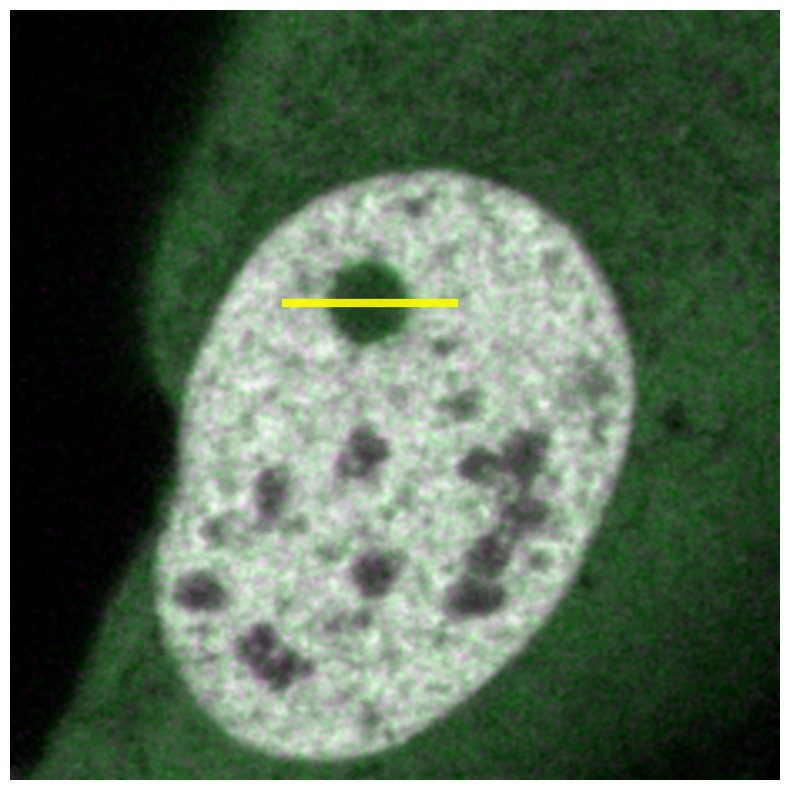

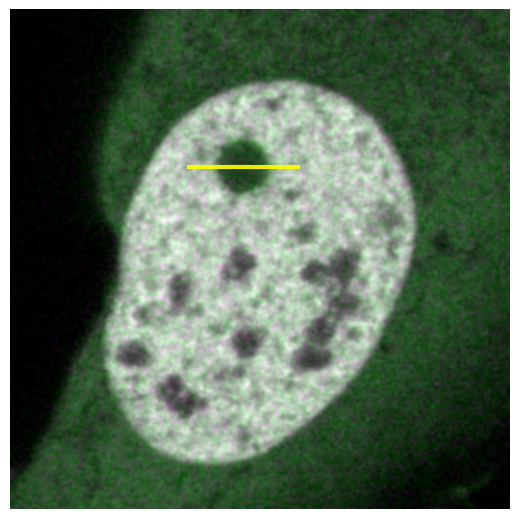

Saved 2 channel images + merged image to: /Users/nzlab-la/Desktop/cotranslational_folding/notebooks/FRAP_analyses/results/kymographs_representative
Image with shape (T Z Y X C):
  (310, 1, 512, 512, 2)
Original Image pixel  min: 0.00, max: 370.00, mean: 9.29, std: 31.20


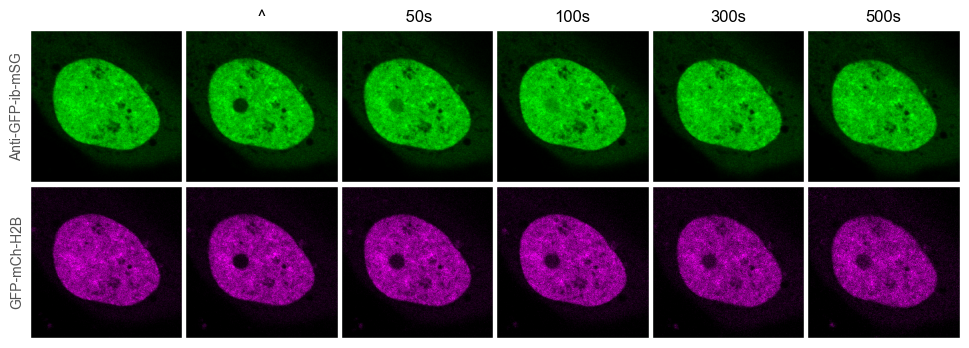

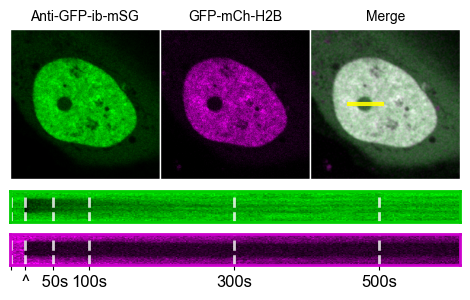

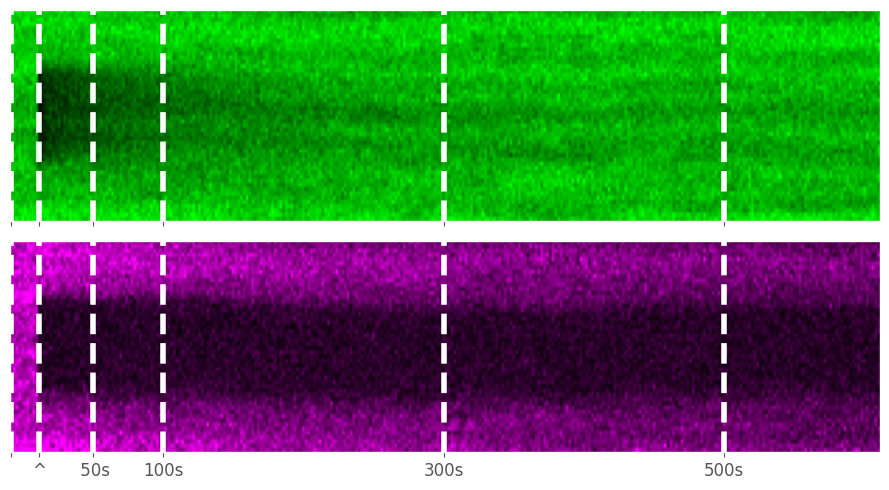

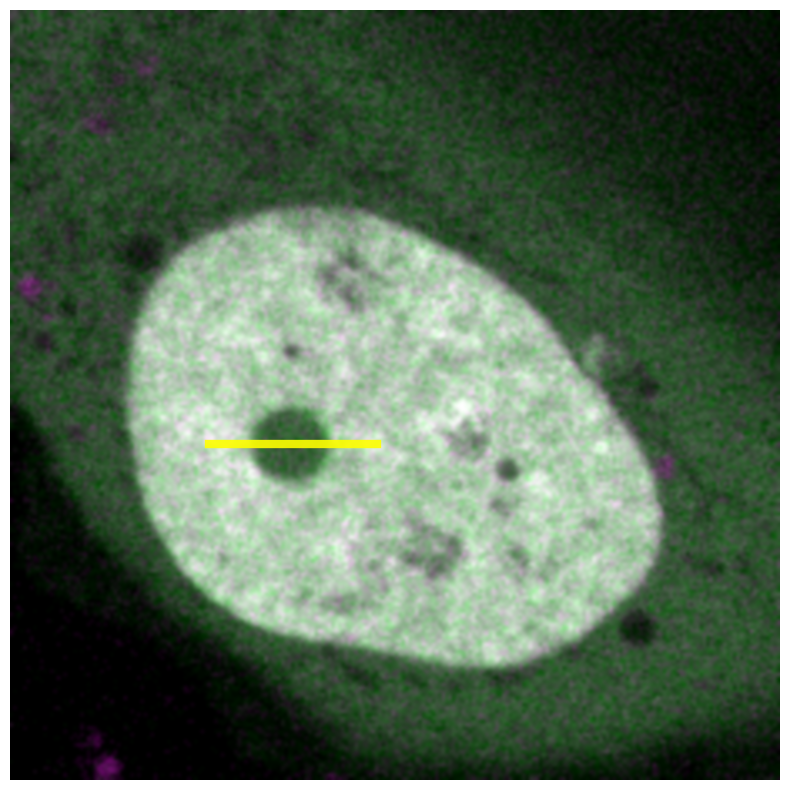

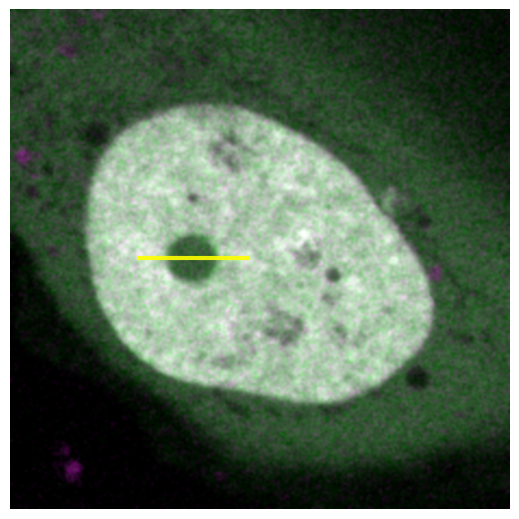

Saved 2 channel images + merged image to: /Users/nzlab-la/Desktop/cotranslational_folding/notebooks/FRAP_analyses/results/kymographs_representative


In [5]:
for index_folder in range (len(list_datasets)):
    list_mean_roi_frap_normalized =[]
    data_folder_path, selected_image_name, list_axis_limits, y_label_list,plot_name= get_data_folder_path(dataset=list_datasets[index_folder])
    list_images, list_names, pixel_xy_um, voxel_z_um, channel_names, number_color_channels,list_time_intervals, bit_depth,_,_,_ = mi.ReadLif(data_folder_path,show_metadata=False,save_tif=False,save_png=False,format='TZYXC').read()
    list_concatenated_images, list_names_concatenated_images,list_time_concatenated = concatenate_images(list_images, list_names,False,list_time_intervals )
    for i in range(len(list_names_concatenated_images)):
        if selected_image_name == list_names_concatenated_images[i]:
            image_TZXYC, image_TZXYC_masked, image_TXY, masks_TXY, pseudo_cytosol_masks_TXY, background_mask,frame_values = create_image_arrays(list_concatenated_images, selected_image=i,FRAP_channel_to_quantify=FRAP_channel_to_quantify,
                                                                                                                    pretrained_model_segmentation=None,frap_time=frap_time, starting_changing_frame=starting_changing_frame, step_size_increase=step_size_increase, min_diameter=radius_roi_size_px*2,segmentation_step_size=10)
            if save_tif:
                name_tif = results_folder / f"{list_datasets[index_folder]}_{selected_image_name.replace(' ', '_')}.tif"
                save_image_as_tiff(image_TZXYC, name_tif, pixel_xy_um=pixel_xy_um, voxel_z_um=voxel_z_um)
            
            list_selected_frames = (  [find_nearest(frame_values, time) for time in list_selected_frame_values_real_time])
            
            mask_intensity_nucleus, mask_intensity_background, mask_intensity_pseudo_cytosol = calculate_mask_and_background_intensity(image_TXY, masks_TXY,background_mask,pseudo_cytosol_masks_TXY)
            
            mean_roi_frap,mean_roi_frap_normalized, coordinates_roi, df_selected_trajectory = find_frap_roi(image_TZXYC_masked,image_TZXYC, masks_TXY, frap_time, min_diameter=radius_roi_size_px*2,FRAP_channel_to_quantify=FRAP_channel_to_quantify, stable_FRAP_channel=stable_FRAP_channel, show_binary_plot=False,
                                                                                                            mask_intensity_background=mask_intensity_background,list_selected_frames=list_selected_frames, use_frap_time_for_roi_detection= True,)
            list_mean_roi_frap_normalized.append(mean_roi_frap_normalized)            
            
            plot_images_frap_all_channels_representative(image_TZXYC, list_selected_frames=list_selected_frames, coordinates_roi=coordinates_roi, radius_roi_size_px=radius_roi_size_px, cmap_list =cmap_list,list_axis_limits=list_axis_limits,show_circle=show_circle,scalebar_size=scalebar_size,
                                            y_label_list=y_label_list,list_selected_frame_values_real_time=list_selected_frame_values_real_time,x_title_list=x_title_list,plot_name=plot_name,masks_TXY=masks_TXY,min_size_image=min_size_image, results_folder=results_folder) 
            
            if show_combined_kymograph:
                path_combined = plot_combined_cell_and_kymograph(image_TZXYC=image_TZXYC,coordinates_roi=coordinates_roi,list_selected_frames=list_selected_frames, x_title_list=x_title_list, length_kymograph_line=length_kymograph_line, cmap_list=cmap_list, y_label_list=y_label_list, masks_TXY=masks_TXY, min_size_image=min_size_image,plot_name=plot_name,pixel_xy_um=pixel_xy_um,scalebar_size=0,line_color_FRAP=line_color_FRAP,
                fig_width=5, fig_height=5, kymograph_ratio=0.1, frame_for_merge=frap_time,gamma=0.6,clip_limit=0.001,dpi=600,results_folder=results_folder,)
                
            if show_kymograph_simple: 
                path_kymograph = plot_kymograph(image_TZXYC, coordinates_roi, list_selected_frames, x_title_list, length_kymograph_line=length_kymograph_line,cmap_list=cmap_list,plot_vertical_lines=True,plot_name=plot_name, results_folder=results_folder)
                path_merged_image = plot_merged_image(image_TZXYC, coordinates_roi, length_kymograph_line,cmap_list, list_axis_limits=list_axis_limits,plot_name=plot_name,masks_TXY=masks_TXY,min_size_image=min_size_image,line_color_FRAP=line_color_FRAP,scalebar_size=scalebar_size, results_folder=results_folder)
                compose_pngs( path_merged_image, path_kymograph, results_folder.joinpath('FRAP_anti-'+plot_name+'.png'), target_height=500)
            if show_individual_images:
                individual_paths = plot_cell_images_individual(
                    image_TZXYC=image_TZXYC,
                    coordinates_roi=coordinates_roi,
                    length_kymograph_line=length_kymograph_line,
                    cmap_list=cmap_list,
                    y_label_list=y_label_list,
                    masks_TXY=masks_TXY,
                    min_size_image=min_size_image,
                    plot_name=plot_name,
                    pixel_xy_um=pixel_xy_um,
                    scalebar_size=scalebar_size,
                    line_color_FRAP=line_color_FRAP,
                    frame_for_images=frap_time,
                    gamma=0.6,
                    clip_limit=0.001,
                    dpi=600,
                    fig_size=5,
                    show_frap_line=True,
                    results_folder=results_folder,
                )
            # Save video
            if save_avi:    
                avi_name = results_folder.joinpath('FRAP_anti-'+plot_name+'.avi')
                path_video = save_video_as_avi(image_TZXYC, avi_name, frame_values, list_axis_limits=list_axis_limits, cmap_list=cmap_list,masks_TXY=masks_TXY, y_label_list=y_label_list, fps=5, pixel_xy_um=pixel_xy_um, scalebar_size=scalebar_size)

